# Cognitive Bias Extraction EDA & Integrity Checks

This notebook validates the output of the LLM cognitive bias extraction across the three elections (us16, us20, us24). It performs integrity checks and explores the prevalence of various biases.


In [15]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from bias_analysis.dataset import get_base_dataset

sns.set_theme(style="whitegrid")



## 1. Load Data & Integrity Checks

We verify that the number of unique IDs in the output exactly matches the number of rows in the input dataset for each election.


In [16]:
elections = ["us16", "us20", "us24"]
processed_dir = Path("../data/processed")

bias_data = {}
base_data = {}

for el in elections:
    print(f"--- {el.upper()} ---")
    
    # Load base dataset
    df_base = get_base_dataset(el)
    base_data[el] = df_base
    print(f"Base dataset rows: {len(df_base)}")
    
    # Load bias outputs
    bias_file = processed_dir / el / "cognitive_biases.jsonl"
    if not bias_file.exists():
        print(f"File non trovato: {bias_file}")
        continue
        
    with open(bias_file, 'r', encoding='utf-8') as f:
        records = [json.loads(line) for line in f]
        
    df_bias = pd.DataFrame(records)
    bias_data[el] = df_bias
    
    print(f"Extracted biases rows: {len(df_bias)}")
    
    # Checks
    duplicates = df_bias['id'].duplicated().sum()
    print(f"Duplicate IDs in output: {duplicates}")
    
    missing = set(df_base['tweet_id'].astype(str)) - set(df_bias['id'].astype(str))
    print(f"Missing IDs (in base but not in output): {len(missing)}")
    print()



--- US16 ---
2026-05-25 19:49:18.216 | INFO     | bias_analysis.dataset:get_base_dataset:351 - Loading cached base dataset from C:\Users\utente\Desktop\Work\TweetPollBias\data\processed\us16\base_dataset_cache.pkl
Base dataset rows: 761
Extracted biases rows: 761
Duplicate IDs in output: 0
Missing IDs (in base but not in output): 0

--- US20 ---
2026-05-25 19:49:18.224 | INFO     | bias_analysis.dataset:get_base_dataset:351 - Loading cached base dataset from C:\Users\utente\Desktop\Work\TweetPollBias\data\processed\us20\base_dataset_cache.pkl
Base dataset rows: 7470
Extracted biases rows: 7470
Duplicate IDs in output: 0
Missing IDs (in base but not in output): 0

--- US24 ---
2026-05-25 19:49:18.265 | INFO     | bias_analysis.dataset:get_base_dataset:351 - Loading cached base dataset from C:\Users\utente\Desktop\Work\TweetPollBias\data\processed\us24\base_dataset_cache.pkl
Base dataset rows: 2727
Extracted biases rows: 2727
Duplicate IDs in output: 0
Missing IDs (in base but not in out

## 2. LLM Hallucination & Formatting Checks

We verify that the LLM adhered strictly to the schema: valid bias names, confidence scores between 0 and 1, etc.


In [17]:
allowed_biases = {
    "None", # No bias detected
    "Confirmation Bias", 
    "Anchoring", 
    "Availability Heuristic", 
    "Social Desirability Bias", 
    "Acquiescence Bias", 
    "Demand Characteristics Bias"
}

all_biases_flat = []

for el, df in bias_data.items():
    for _, row in df.iterrows():
        # Handle cases where biases_detected might be missing or empty
        biases = row.get('biases_detected', [])
        if not isinstance(biases, list):
            print(f"[{el}] Invalid biases_detected format for ID {row['id']}")
            continue
            
        for b in biases:
            b_type = b.get('bias_type')
            conf = b.get('confidence_score')
            
            # Check for hallucinated bias types
            if b_type not in allowed_biases:
                print(f"[{el}] HALLUCINATED BIAS TYPE: '{b_type}' in ID {row['id']}")
                
            # Check confidence score bounds
            try:
                conf = float(conf)
                if not (0.0 <= conf <= 1.0):
                    print(f"[{el}] INVALID CONFIDENCE SCORE: {conf} in ID {row['id']}")
            except (ValueError, TypeError):
                print(f"[{el}] NON-NUMERIC CONFIDENCE SCORE: {conf} in ID {row['id']}")
                
            all_biases_flat.append({
                'election': el,
                'id': row['id'],
                'bias_type': b_type,
                'confidence_score': conf
            })

df_flat = pd.DataFrame(all_biases_flat)
print(f"Total individual biases detected across all elections: {len(df_flat)}")



Total individual biases detected across all elections: 4095


## 3. Exploratory Data Analysis

Let's analyze the distribution of cognitive biases.


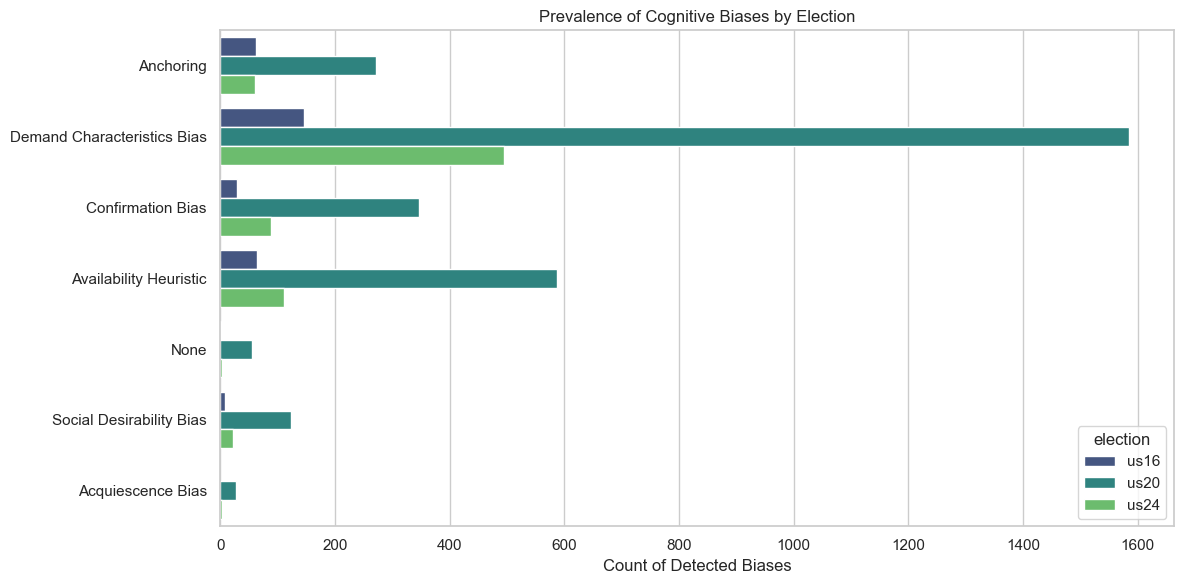

In [ ]:
# Distribution of biases per election
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_flat, y='bias_type', hue='election', palette='viridis')
plt.title('Prevalence of Cognitive Biases by Election')
plt.xlabel('Count of Detected Biases')
plt.ylabel('')
plt.tight_layout()
plt.show()



In [19]:
# Percentage of polls containing AT LEAST ONE bias
for el in elections:
    if el not in bias_data: continue
    df = bias_data[el]
    
    def has_bias(x):
        return isinstance(x, list) and len(x) > 0
        
    biased_polls = df['biases_detected'].apply(has_bias).sum()
    total_polls = len(df)
    perc = (biased_polls / total_polls) * 100 if total_polls > 0 else 0
    print(f"{el.upper()}: {biased_polls}/{total_polls} polls ({perc:.1f}%) contain at least one bias.")



US16: 310/761 polls (40.7%) contain at least one bias.
US20: 2962/7470 polls (39.7%) contain at least one bias.
US24: 783/2727 polls (28.7%) contain at least one bias.


C:\Users\utente\AppData\Local\Temp\ipykernel_3048\1061801815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_flat, y='bias_type', x='confidence_score', palette='magma')


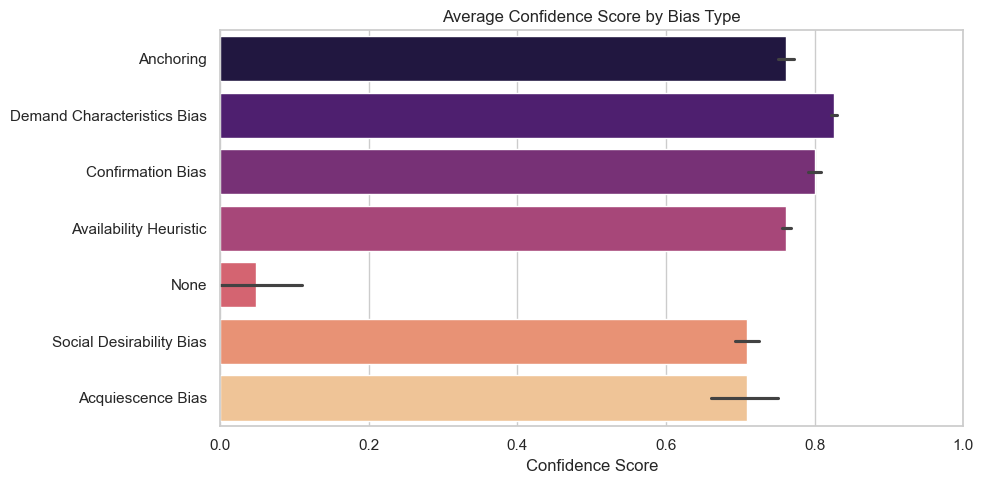

In [20]:
# Average confidence score per bias type
plt.figure(figsize=(10, 5))
sns.barplot(data=df_flat, y='bias_type', x='confidence_score', palette='magma')
plt.title('Average Confidence Score by Bias Type')
plt.xlabel('Confidence Score')
plt.ylabel('')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

